# Week 2 · Task 1 — A numerical gradient checker

**Roadmap task:** *A numerical gradient checker in NumPy. Twenty lines. You will still be using it in Week 26 to catch bugs in neural networks.*

The code lives in `mathkit/gradcheck.py` (the core function is ~15 lines) and is tested in `tests/test_gradcheck.py`.

**What this notebook shows**

1. The idea: the definition of the derivative *is* the checker.
2. Why we use the **centred** difference, and how to choose `eps` (with a plot).
3. Checking hand-derived gradients: a 3-variable function, and a 3-function chain rule (Gate 1, question 1).
4. Watching it **catch a bug**.
5. A preview of Week 11: checking the logistic-regression gradient.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.gradcheck import numerical_gradient, gradient_check, relative_error

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(suppress=True, precision=6)

## 1. The idea

**In simple words:** a derivative answers *"if I nudge the input a tiny bit, how much does the output move?"* So — nudge it and measure.

For a function of many inputs, nudge **one input at a time** (that gives one *partial* derivative), and collect them into the gradient vector:

$$\frac{\partial f}{\partial x_i} \approx \frac{f(\vec x + \varepsilon\,\vec e_i) - f(\vec x - \varepsilon\,\vec e_i)}{2\varepsilon}$$

where $\vec e_i$ is "1 in position $i$, 0 elsewhere". The core loop in `numerical_gradient`:

```python
for each index i of x:
    original = x[i]
    x[i] = original + eps;  f_plus  = f(x)
    x[i] = original - eps;  f_minus = f(x)
    x[i] = original                       # put it back!
    grad[i] = (f_plus - f_minus) / (2 * eps)
```

It works for vectors *and* matrices (it loops over every entry), which is exactly what you need for neural-network weight matrices in Week 19.

**Cost:** 2 function calls per parameter. Fine for checking, far too slow for training — that is why we derive gradients by hand (and why backpropagation exists).

## 2. Why "centred", and how small should `eps` be?

Taylor expansion (3Blue1Brown Calculus ch. 11) explains it:

$$f(x+\varepsilon) = f(x) + \varepsilon f'(x) + \tfrac{\varepsilon^2}{2} f''(x) + \tfrac{\varepsilon^3}{6}f'''(x) + \dots$$

* **One-sided** $\frac{f(x+\varepsilon)-f(x)}{\varepsilon} = f'(x) + \tfrac{\varepsilon}{2}f''(x) + \dots$ → error shrinks like $\varepsilon$.
* **Centred** $\frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon} = f'(x) + \tfrac{\varepsilon^2}{6}f'''(x) + \dots$ → the $\varepsilon^2$ terms cancel, error shrinks like $\varepsilon^2$.

But `eps` can't be *too* small: computers store about 16 significant digits, so subtracting two almost-equal numbers loses precision (**round-off error** grows like $10^{-16}/\varepsilon$). The best `eps` balances the two. Let's measure it on $f(x) = \sin x$ at $x = 1$, where we know $f'(1) = \cos 1$ exactly.

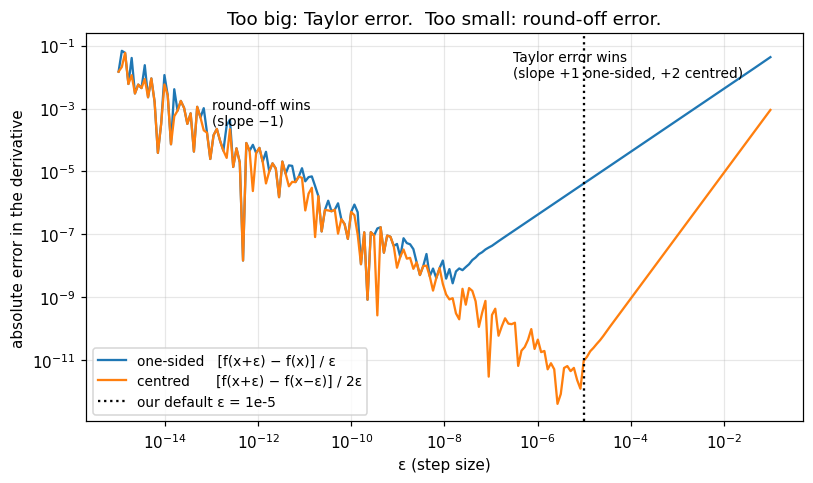

eps = 1e-02:   one-sided error 4.2e-03    centred error 9.0e-06
eps = 1e-05:   one-sided error 4.2e-06    centred error 1.1e-11
eps = 1e-08:   one-sided error 3.0e-09    centred error 2.6e-09
eps = 1e-12:   one-sided error 4.3e-05    centred error 1.2e-05


In [2]:
f, x0, true = np.sin, 1.0, np.cos(1.0)
eps_values = np.logspace(-15, -1, 200)
one_sided = np.abs((f(x0 + eps_values) - f(x0)) / eps_values - true)
centred = np.abs((f(x0 + eps_values) - f(x0 - eps_values)) / (2 * eps_values) - true)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_values, one_sided, label="one-sided   [f(x+ε) − f(x)] / ε")
ax.loglog(eps_values, centred, label="centred      [f(x+ε) − f(x−ε)] / 2ε")
ax.axvline(1e-5, color="k", ls=":", label="our default ε = 1e-5")
ax.set_xlabel("ε (step size)"); ax.set_ylabel("absolute error in the derivative")
ax.set_title("Too big: Taylor error.  Too small: round-off error.")
ax.annotate("round-off wins\n(slope −1)", xy=(1e-13, 3e-4), fontsize=9)
ax.annotate("Taylor error wins\n(slope +1 one-sided, +2 centred)", xy=(3e-7, 1e-2), fontsize=9)
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "w2_eps_choice.png", dpi=150); plt.show()

for e in [1e-2, 1e-5, 1e-8, 1e-12]:
    o = abs((f(x0 + e) - f(x0)) / e - true); c = abs((f(x0 + e) - f(x0 - e)) / (2 * e) - true)
    print(f"eps = {e:.0e}:   one-sided error {o:.1e}    centred error {c:.1e}")

The V-shapes are the whole story. At $\varepsilon = 10^{-5}$ the centred version is roughly a million times more accurate than the one-sided one; the one-sided version needs a much smaller $\varepsilon$ (around $10^{-8}$), and even there it is hundreds of times less accurate than the centred version at $10^{-5}$. (The very lowest points on the jagged left side are lucky round-off, not something you can rely on.) That is why the checker uses the centred difference with $\varepsilon = 10^{-5}$.

## 3. How to read the result: relative error

We compare the numeric gradient $\vec n$ with your analytic gradient $\vec a$ using

$$\text{rel. error} = \frac{\|\vec n - \vec a\|}{\|\vec n\| + \|\vec a\|}$$

Dividing by the sizes makes it scale-free (a gradient of size 1000 and one of size 0.001 are judged by the same yardstick).

| relative error | verdict |
|---|---|
| < 1e-7 | ✅ correct |
| 1e-7 … 1e-4 | ⚠️ suspicious — check for kinks (ReLU, abs) |
| > 1e-4 | ❌ bug in your derivation or code |

## 4. Check a hand-derived gradient — a 3-variable function

$$f(x, y, z) = x^2 y + \sin(yz) + e^x$$

By hand, treating the other variables as constants each time:

$$\frac{\partial f}{\partial x} = 2xy + e^x, \qquad \frac{\partial f}{\partial y} = x^2 + z\cos(yz), \qquad \frac{\partial f}{\partial z} = y\cos(yz)$$

In [3]:
def f3(v):
    x, y, z = v
    return x**2 * y + np.sin(y * z) + np.exp(x)

def grad_f3(v):
    x, y, z = v
    return np.array([2*x*y + np.exp(x),
                     x**2 + z*np.cos(y*z),
                     y*np.cos(y*z)])

point = np.array([0.5, -1.2, 2.0])
passed, err, num, ana = gradient_check(f3, grad_f3, point, verbose=True)
print("numeric :", num)
print("analytic:", ana)

[PASS] relative error = 2.967e-11  (tol = 1e-06)
numeric : [ 0.448721 -1.224787  0.884872]
analytic: [ 0.448721 -1.224787  0.884872]


## 5. The chain rule for three functions (Gate 1, question 1)

$$h(x) = e^{\sin(x^2)} \quad = \quad f(g(k(x))) \text{ with } k(x)=x^2,\; g(u)=\sin u,\; f(w)=e^w$$

**In simple words:** a pipeline of three machines. Nudging $x$ nudges $k$ by $k'$, which nudges $g$ by $g'$ times that, which nudges $f$ by $f'$ times *that*. Sensitivities **multiply**:

$$h'(x) = f'(g(k(x)))\cdot g'(k(x))\cdot k'(x) = e^{\sin(x^2)}\cdot\cos(x^2)\cdot 2x$$

This "multiply the local sensitivities along the pipeline" rule is *all* backpropagation is (Week 19).

In [4]:
h = lambda x: np.exp(np.sin(x[0] ** 2))
dh = lambda x: np.array([np.exp(np.sin(x[0]**2)) * np.cos(x[0]**2) * 2 * x[0]])
for x in [-1.3, 0.0, 0.7, 2.1]:
    gradient_check(h, dh, [x], verbose=True)

[PASS] relative error = 1.883e-10  (tol = 1e-06)
[PASS] relative error = 0.000e+00  (tol = 1e-06)
[PASS] relative error = 1.304e-11  (tol = 1e-06)
[PASS] relative error = 1.120e-10  (tol = 1e-06)


## 6. Watch it catch a bug

A very common mistake in the chain rule: **forgetting the inner derivative**. Suppose you wrote $h'(x) = e^{\sin(x^2)}\cos(x^2)$ and forgot the $2x$:

In [5]:
dh_wrong = lambda x: np.array([np.exp(np.sin(x[0]**2)) * np.cos(x[0]**2)])   # forgot "* 2x"
gradient_check(h, dh_wrong, [0.7], verbose=True);

# Another classic: a sign error in the 3-variable gradient (dz term)
def grad_f3_wrong(v):
    g = grad_f3(v); g[2] = -g[2]; return g
gradient_check(f3, grad_f3_wrong, point, verbose=True);

[FAIL] relative error = 1.667e-01  (tol = 1e-06)
        worst entry (0,): numeric=1.97766, analytic=1.41261
[FAIL] relative error = 5.614e-01  (tol = 1e-06)
        worst entry (2,): numeric=0.884872, analytic=-0.884872


The checker even tells you **which entry** is wrong — so you know which partial derivative to re-derive.

## 7. Preview of Week 11 — logistic regression's gradient, on a weight *vector*

Loss: $L(\vec w) = -\frac1n\sum_i \big[y_i\log p_i + (1-y_i)\log(1-p_i)\big]$ with $p_i = \sigma(\vec x_i\cdot\vec w)$.

You will derive in Week 11 that the gradient is beautifully simple: $\nabla L = \frac1n X^\top(\vec p - \vec y)$ — *"predicted minus actual"*. Today we just check it:

In [6]:
rng = np.random.default_rng(0)
X = rng.normal(size=(50, 4)); y = rng.integers(0, 2, 50)
sigmoid = lambda z: 1 / (1 + np.exp(-z))

def logloss(w):
    p = sigmoid(X @ w)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def logloss_grad(w):
    return X.T @ (sigmoid(X @ w) - y) / len(y)

gradient_check(logloss, logloss_grad, rng.normal(size=4), verbose=True);

# And on a MATRIX of weights (what a neural network layer has):
W = rng.normal(size=(3, 2))
g = numerical_gradient(lambda M: np.sum(np.tanh(M) ** 2), W)
print("\nnumeric gradient of sum(tanh(W)^2) has shape", g.shape, "- same as W")
print("matches 2·tanh(W)·(1 − tanh(W)²)?", np.allclose(g, 2*np.tanh(W)*(1 - np.tanh(W)**2), atol=1e-8))

[PASS] relative error = 1.093e-11  (tol = 1e-06)

numeric gradient of sum(tanh(W)^2) has shape (3, 2) - same as W
matches 2·tanh(W)·(1 − tanh(W)²)? True


## 8. One warning — kinks

At a point where a function has a sharp corner (like $|x|$ at 0, or ReLU at 0), the derivative does not exist. If the input sits closer to the corner than `eps`, the two nudges land on *opposite sides* of the corner and the checker averages two different slopes. Below, $x_1 = 10^{-7}$ is closer to 0 than $\varepsilon = 10^{-5}$, so the check fails even though `np.sign` is the correct derivative there. This is not a bug in your gradient — when it happens in a neural network, move the check point away from the kink.

In [7]:
gradient_check(lambda x: np.abs(x).sum(), lambda x: np.sign(x), np.array([1e-7, 2.0]), verbose=True);

[FAIL] relative error = 4.101e-01  (tol = 1e-06)
        worst entry (0,): numeric=0.01, analytic=1


## 9. Your turn

1. By hand, find the gradient of $f(x,y,z) = x e^{yz} + y^2 z$. Code both `f` and `grad_f`, then run `gradient_check`.
2. Derive $\frac{d}{dx}\ln(1 + e^{3x^2})$ with the chain rule (three functions). Check it.
3. Deliberately put a bug in your answer to (1) and see which entry the checker blames.
4. **Explain out loud:** "Why can't we just train models with numerical gradients?" (Hint: count function calls for a model with 1 million weights.)